<a href="https://colab.research.google.com/github/liminalvoid/cv-project/blob/main/sem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 3. Линейная классификация текстов в sklearn: Logistic Regression

## Настройки и импорт необходимых библиотек

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from datasets import load_dataset


RANDOM_SEED = 52

np.random.seed(RANDOM_SEED)

# Увеличение размера графиков
plt.rcParams["figure.dpi"] = 140

## Исходные данные

Исходные данные – сообщения на форуме «Двач» с указанным эмоциональным интентом.

In [3]:
ru_emotion_dvach_ds = load_dataset("Kostya165/ru_emotion_dvach")
ru_emotion_dvach_ds

README.md: 0.00B [00:00, ?B/s]

train_part_1.csv: 0.00B [00:00, ?B/s]

train_part_2.csv: 0.00B [00:00, ?B/s]

train_part_3.csv: 0.00B [00:00, ?B/s]

train_part_4.csv: 0.00B [00:00, ?B/s]

...

train_part_6.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/59061 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2507 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 59061
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2507
    })
})

Выбранные классы – `aggression` и `sarcasm`.

In [4]:
selected_classes = ["aggression", "sarcasm"]

ds_filtered = ru_emotion_dvach_ds.filter(
    lambda example: (
        example["label"] in selected_classes and
        example["text"] # Также отфильтруем пустые строки
    )
)
labels_count = Counter(ds_filtered["train"]["label"])

print(f"Количество документов: {len(ds_filtered["train"]) + len(ds_filtered["validation"])}\n")

print("Баланс классов:")
{print(f"- Класс `{name}`: {count}") for name, count in labels_count.items()};

Filter:   0%|          | 0/59061 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2507 [00:00<?, ? examples/s]

Количество документов: 24515

Баланс классов:
- Класс `sarcasm`: 11693
- Класс `aggression`: 11820


Данные в исходном датасете разбиты на тренировочные и валидационные. Далее разобъем валидационную выборку на тестовую и валидационную в соотношении 1 к 1.

In [5]:
df_train = ds_filtered["train"].to_pandas()
X_train, y_train = np.array(df_train["text"], dtype=object), np.array(df_train["label"])

df_validation = ds_filtered["validation"].to_pandas()
X_val, X_test, y_val, y_test = train_test_split(
    df_validation["text"],
    df_validation["label"],
    test_size=0.5,
    stratify=df_validation["label"],
    random_state=RANDOM_SEED,
)

[
    print(f"{label}: {size}")
    for label, size in zip(
        ["train", "validation", "test"],
        [len(X_train), len(X_val), len(X_test)]
    )
];

train: 23513
validation: 501
test: 501


## Базовый векторайзер (TF-IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro-F1. Подбор гиперпараметров (eta, tol, max_iter). Предобработка для "мешка слов"

### Логистическая регрессия и подбор степени регуляризации

Используем пайплайн из TF-IDF векторайзера и логистической регрессии и подберем оптимальный параметр степени регуляризации $\alpha$.

In [8]:
# Убрать вывод для текущей клетки
%%capture

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1]
results = []

for a in alphas:
    model = Pipeline([
        (
            "vec",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                ngram_range=(1, 1),
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=a,
                learning_rate="constant",
                eta0=0.02,
                max_iter=30,
                tol=1e-6,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")

    results.append((a, acc, f1))

Выберем лучший параметр по macro-F1.

In [11]:
best_alpha, best_acc, best_f1 = sorted(
    results,
    key=lambda x: x[2],
    reverse=True
)[0]

print("Результаты (alpha, acc_val, f1_val):")

for a, acc, f1 in results:
    print(f"alpha={a:<8g} acc={acc:.3f}   f1_val={f1:.3f}")

print(
    "\nЛучший alpha:",
    best_alpha,
    "| acc_val:",
    best_acc,
    "| f1_val:",
    best_f1
)

Результаты (alpha, acc_val, f1_val):
alpha=1e-06    acc=0.934   f1_val=0.934
alpha=1e-05    acc=0.934   f1_val=0.934
alpha=0.0001   acc=0.932   f1_val=0.932
alpha=0.001    acc=0.906   f1_val=0.906
alpha=0.01     acc=0.892   f1_val=0.892
alpha=0.1      acc=0.731   f1_val=0.710
alpha=1        acc=0.499   f1_val=0.333

Лучший alpha: 1e-06 | acc_val: 0.9341317365269461 | f1_val: 0.9340939260215979


Обучим финальную модель с наилучшей степенью регуляризации.

In [12]:
best_sgd_lr = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=0.02,
            max_iter=30,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])
best_sgd_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec', TfidfVectorizer(min_df=3)),
                ('clf',
                 SGDClassifier(alpha=1e-06, eta0=0.02, learning_rate='constant',
                               loss='log_loss', max_iter=30, random_state=52,
                               tol=1e-06))])

Оценка на валидационной/тестовой выборках для лучшей модели.

In [13]:
y_val_pred = best_sgd_lr.predict(X_val)
y_test_pred = best_sgd_lr.predict(X_test)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"))

print(
    "\nОтчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique()
    ),
)

Validation accuracy: 0.9341317365269461
Validation macro-F1: 0.9340939260215979 

Test accuracy: 0.9241516966067864
Test macro-F1: 0.924042451324609

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.89      0.96      0.93       250
     sarcasm       0.96      0.88      0.92       251

    accuracy                           0.92       501
   macro avg       0.93      0.92      0.92       501
weighted avg       0.93      0.92      0.92       501



Построим матрицу несоответствий.

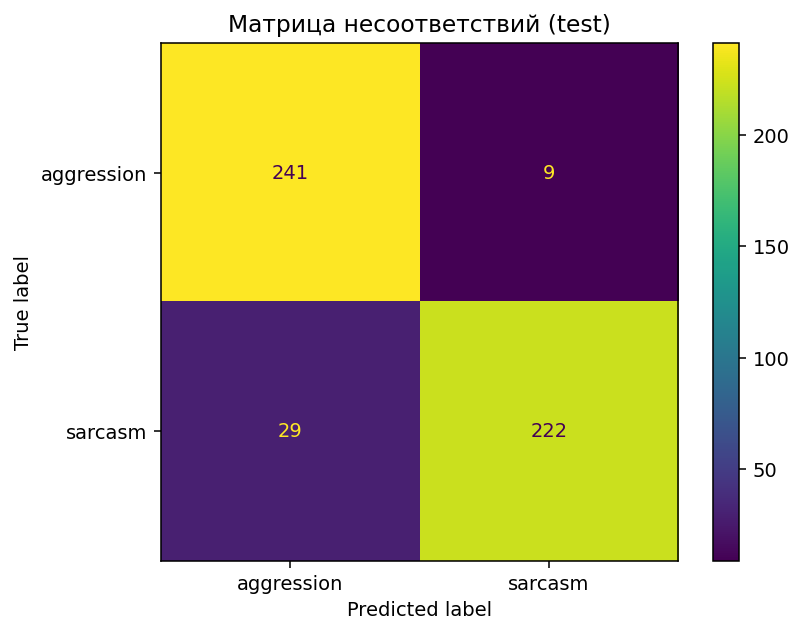

In [14]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_sgd_lr,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

### Поиск гиперпараметров

Произведем подбор гиперпараметров с помощью `GridSearchCV`.

In [125]:
# Команда для отключения текущей клетки
#%%script false --no-raise-error
# Убрать вывод для текущей клетки
%%capture

parameters = {
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1],
    "clf__eta0": [1e-4, 1e-3, 1e-2, 0.1, 1],
    "clf__tol": [1e-4, 1e-3, 1e-2],
    "clf__max_iter": [100, 500, 1000, 2000],
}

pipeline = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            learning_rate="constant",
            random_state=RANDOM_SEED,
        ),
    ),
])

clf = GridSearchCV(pipeline, parameters, n_jobs=-1)
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Ниже приведены наилучшие параметры, полученные после подбора.

In [127]:
clf.best_params_

{'clf__alpha': 1e-06,
 'clf__eta0': 0.01,
 'clf__max_iter': 500,
 'clf__tol': 0.0001}

Оценка на тренировочном и валидационном датасетах для модели с полученными гиперпараметрами.

In [129]:
y_test_pred = clf.predict(X_test)
y_val_pred = clf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"), "\n")

print(
    "Отчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique(),
    ),
)

Validation accuracy: 0.9441117764471058
Validation macro-F1: 0.9441097724230254 

Test accuracy: 0.9321357285429142
Test macro-F1: 0.9321138211382114 

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.92      0.95      0.93       250
     sarcasm       0.95      0.91      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



Построим матрицу несоответствий.

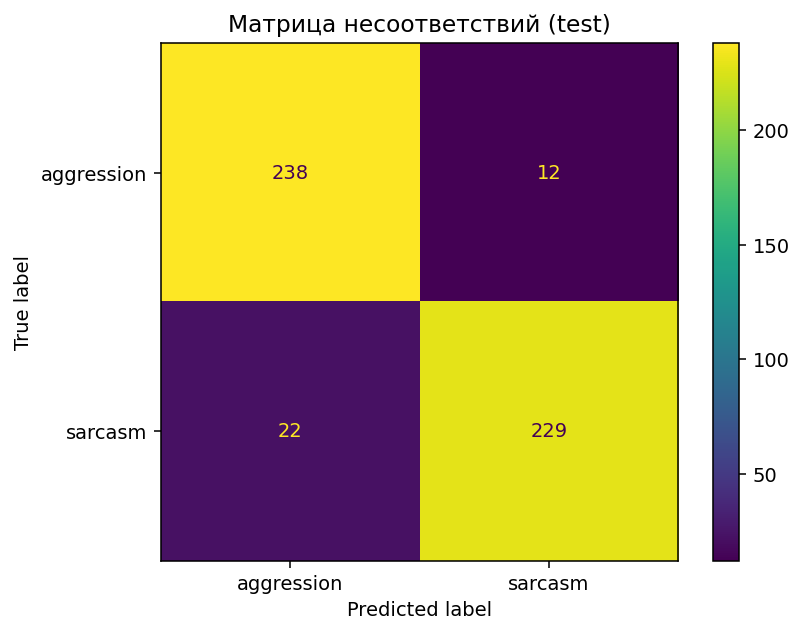

In [131]:
disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

## Линейный SVM (подбор C)

Произведем подбор параметра регуляризации для линейного SVC по аналогии с логистической регрессией выше.

In [39]:
# Убрать вывод для текущей клетки
%%capture

Cs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1]
results = []

for C in Cs:
    model = Pipeline([
        (
            "vec",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                ngram_range=(1, 1),
            ),
        ),
        (
            "clf",
            LinearSVC(
                loss="hinge",
                penalty="l2",
                C=C,
                max_iter=30,
                tol=1e-6,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")

    results.append((C, acc, f1))

Выберем лучший параметр по macro-F1.

In [40]:
best_C, best_acc, best_f1 = sorted(
    results,
    key=lambda x: x[2],
    reverse=True
)[0]

print("Результаты (alpha, acc_val, f1_val):")

for C, acc, f1 in results:
    print(f"C={C:<8g} acc={acc:.3f}   f1_val={f1:.3f}")

print(
    "\nЛучший C:",
    best_C,
    "| acc_val:",
    best_acc,
    "| f1_val:",
    best_f1
)

Результаты (alpha, acc_val, f1_val):
C=1e-06    acc=0.645   f1_val=0.594
C=1e-05    acc=0.645   f1_val=0.594
C=0.0001   acc=0.645   f1_val=0.594
C=0.001    acc=0.645   f1_val=0.594
C=0.01     acc=0.884   f1_val=0.883
C=0.1      acc=0.922   f1_val=0.922
C=1        acc=0.936   f1_val=0.936

Лучший C: 1 | acc_val: 0.936127744510978 | f1_val: 0.9361213821241872


Обучим финальную модель с наилучшей степенью регуляризации.

In [41]:
best_svc_lr = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        LinearSVC(
            loss="hinge",
            penalty="l2",
            C=best_C,
            max_iter=30,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])
best_svc_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('vec', TfidfVectorizer(min_df=3)),
                ('clf',
                 LinearSVC(C=1, loss='hinge', max_iter=30, random_state=52,
                           tol=1e-06))])

Оценка на валидационной/тестовой выборках для лучшей модели.

In [42]:
y_val_pred = best_svc_lr.predict(X_val)
y_test_pred = best_svc_lr.predict(X_test)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"))

print(
    "\nОтчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique()
    ),
)

Validation accuracy: 0.936127744510978
Validation macro-F1: 0.9361213821241872 

Test accuracy: 0.9281437125748503
Test macro-F1: 0.9281205164992827

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.91      0.95      0.93       250
     sarcasm       0.95      0.91      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



Построим матрицу несоответствий.

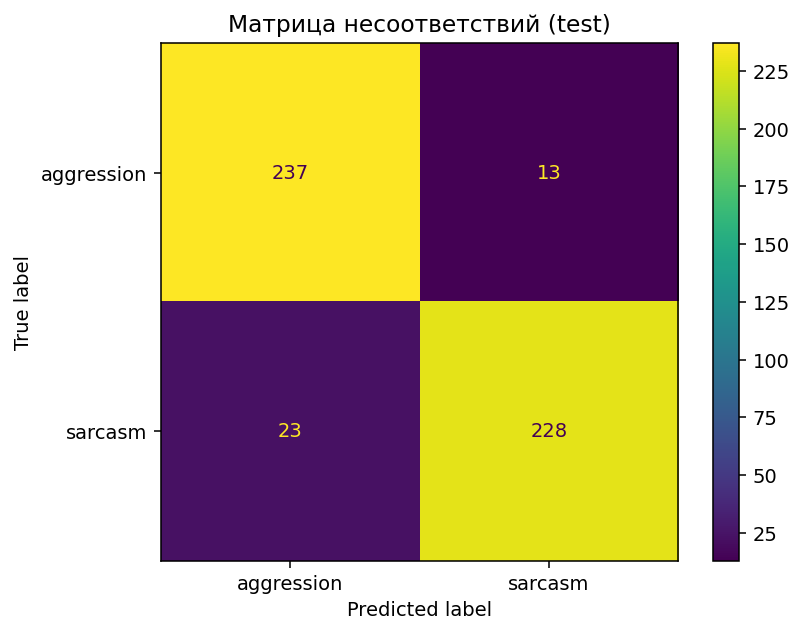

In [43]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_svc_lr,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

Полученные наилучшие параметры $C$ и $\alpha$: 1 и 1e-6 соответственно. Приблизительное соотношение этих двух параметров можно выразить следующим образом:

$$
C \approx \frac{1}{\alpha \times n}
$$

Следовательно, в то время как $\alpha$ стремится к нулю, $C$ стремится к бесконечности.

Исходя из полученных метрик, линейный SVM классифицировал отобранные интенты лучше, чем логистическая регрессия.

Наилучшие параметры, полученные с помощью `GridSearchCV`:

- alpha: 1e-06
- eta0: 0.01
- max_iter: 500
- tol: 0.0001

## Добавление L1-регуляризации. Вывод топ-признаков